# DNA learning results

Run `dna_learning.py` to generate data; this notebook only loads results and plots them.
From this directory, for example:

```bash
/home/shazoop/miniconda3/envs/conin/bin/python dna_learning.py
```

The script defaults to 20 trials, 30 sequences per trial, and at most 500 outer
iterations. Use `--help` to change these settings, or `--output PATH` to choose
the JSON destination. Completed trials are saved after each trial; rerunning
the script starts a new experiment.

Set `DATA_PATH` below to the saved JSON. The plots match the learning figures in
`dna_clean.ipynb`. Objective values describe different likelihoods and should not
be used to rank methods directly. Iteration counts include capped runs, and
parameter errors are descriptive because conditioning can affect identifiability.


In [7]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


In [8]:
DATA_PATH = Path('learning_data_gem_v3.json')

with DATA_PATH.open() as f:
    data = json.load(f)
completed = data.get('completed_trials', len(data['constrained_steps']))
if completed == 0:
    raise ValueError('No completed trials in the results file')
print(f"Loaded {completed}/{data['settings']['num_trials']} trials from {DATA_PATH.resolve()}")
print(data['settings'])


Loaded 20/20 trials from /home/fyqiu/Projects/conin/conin/mediation_variables/ICML26_code/TMLR_code/learning_data_gem_v3.json
{'seed': 23, 'num_trials': 20, 'num_samples': 50, 'time_horizon': 60, 'pro_before': 10, 'max_iter': 500, 'tol': 0.001, 'inner_max_iter': 30, 'inner_tol': 1e-06, 'step_size': 0.8, 'max_backtracks': 30, 'dtype': 'float64', 'device': 'cuda:0'}


In [9]:
methods = [
    ('Conditional GEM', 'log p(y | C_T)', data['constrained_steps'],
     data['constrained_terminal_loglik'], data['constrained_init_l2'], data['constrained_trans_l2'], data['constrained_emit_l2']),
    ('Joint BW', 'log p(y, C_T)', data['joint_steps'],
     data['joint_terminal_loglik'], data['joint_init_l2'], data['joint_trans_l2'], data['joint_emit_l2']),
    ('Unconstrained BW', 'log p(y)', data['unconstrained_steps'],
     data['unconstrained_terminal_loglik'], data['unconstrained_init_l2'], data['unconstrained_trans_l2'], data['unconstrained_emit_l2']),
]

for label, objective, steps, scores, init_errors, trans_errors, emit_errors in methods:
    print(f'{label}: {objective}')
    for name, values in [
        ('completed iterations', steps), ('terminal log-likelihood', scores),
        ('init L2 error', init_errors), ('trans L2 error', trans_errors),
        ('emit L2 error', emit_errors),
    ]:
        print(f'  Mean {name}: {np.mean(values):.6f}')
        print(f'  Std  {name}: {np.std(values):.6f}')
    print()



Conditional GEM: log p(y | C_T)
  Mean completed iterations: 488.450000
  Std  completed iterations: 37.518629
  Mean terminal log-likelihood: -3724.003468
  Std  terminal log-likelihood: 28.477398
  Mean init L2 error: 0.668036
  Std  init L2 error: 0.148626
  Mean trans L2 error: 1.553663
  Std  trans L2 error: 0.132221
  Mean emit L2 error: 1.197183
  Std  emit L2 error: 0.248184

Joint BW: log p(y, C_T)
  Mean completed iterations: 80.900000
  Std  completed iterations: 39.678584
  Mean terminal log-likelihood: -4010.778694
  Std  terminal log-likelihood: 22.712972
  Mean init L2 error: 0.699033
  Std  init L2 error: 0.019430
  Mean trans L2 error: 1.854082
  Std  trans L2 error: 0.063903
  Mean emit L2 error: 1.136254
  Std  emit L2 error: 0.213736

Unconstrained BW: log p(y)
  Mean completed iterations: 463.900000
  Std  completed iterations: 52.684818
  Mean terminal log-likelihood: -3968.681573
  Std  terminal log-likelihood: 28.131470
  Mean init L2 error: 1.001416
  Std  init

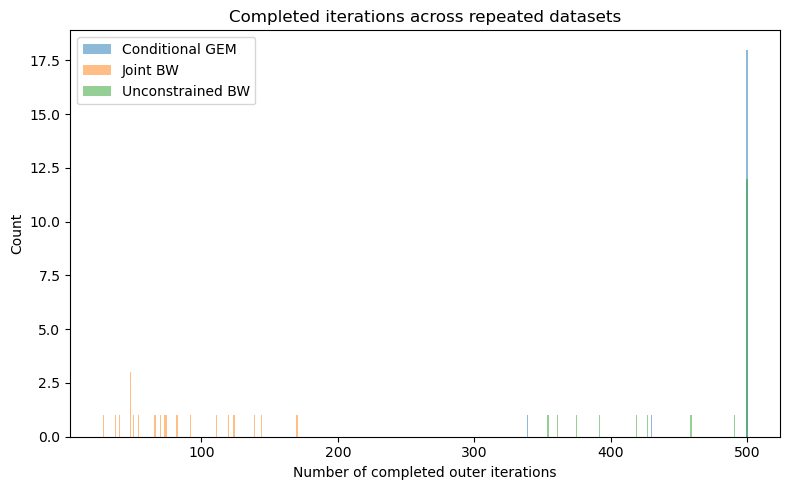

In [10]:
bins = np.arange(min(min(m[2]) for m in methods),
                 max(max(m[2]) for m in methods) + 2) - 0.5
plt.figure(figsize=(8, 5))
for label, _, steps, *_ in methods:
    plt.hist(steps, bins=bins, alpha=0.5, label=label)
plt.xlabel('Number of completed outer iterations')
plt.ylabel('Count')
plt.title('Completed iterations across repeated datasets')
plt.legend()
plt.tight_layout()
plt.show()



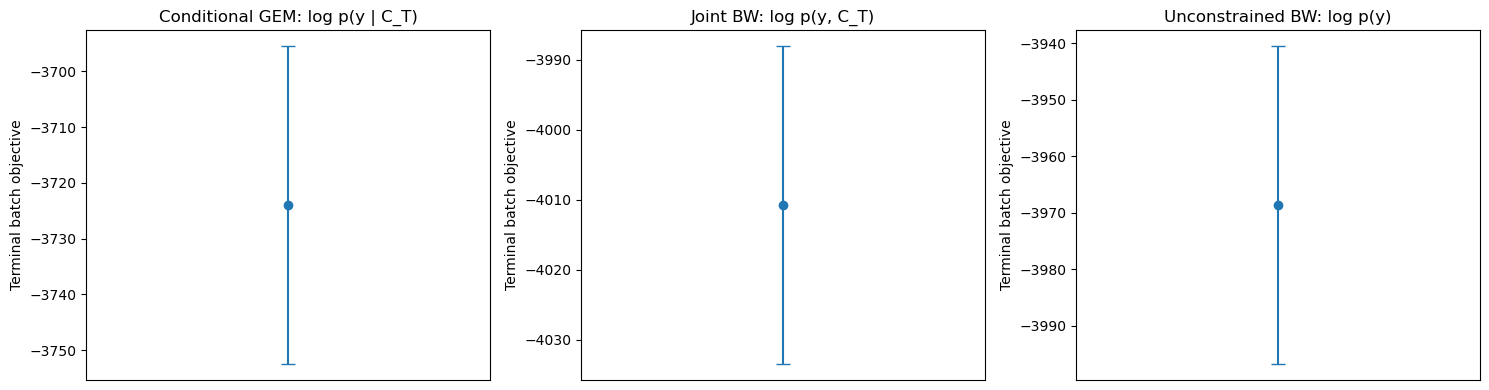

In [11]:
# Each objective has its own axis; their magnitudes are not a fit ranking.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (label, objective, _, scores, *_) in zip(axes, methods):
    ax.errorbar([0], [np.mean(scores)], yerr=[np.std(scores)], fmt='o', capsize=5)
    ax.set_xticks([])
    ax.set_title(f'{label}: {objective}')
    ax.set_ylabel('Terminal batch objective')
plt.tight_layout()
plt.show()



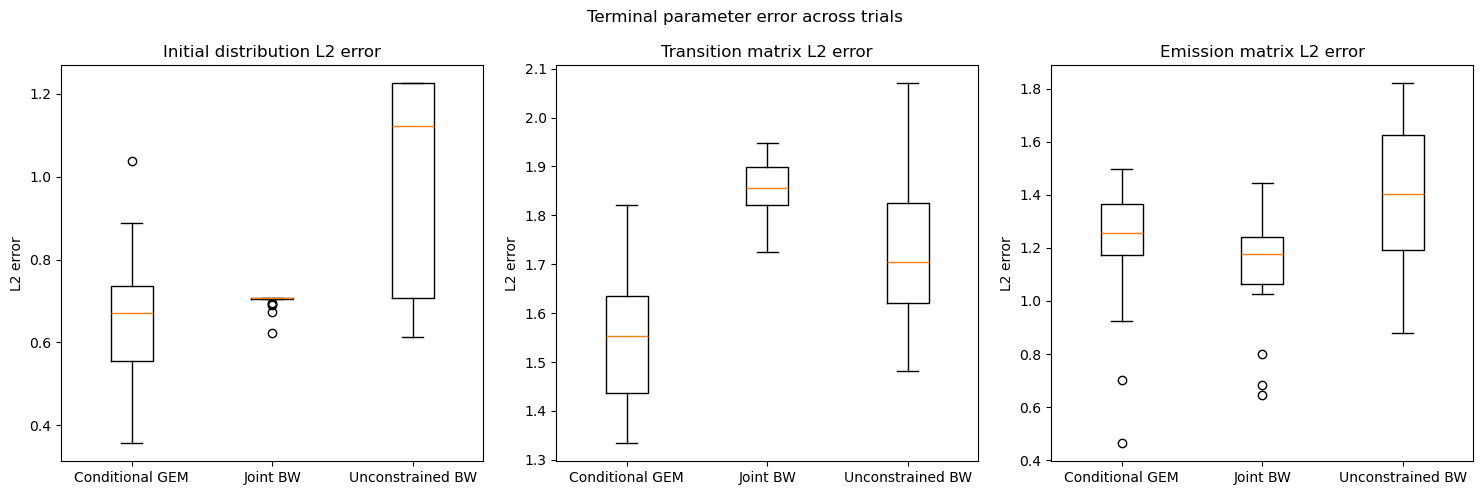

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, index, title in zip(axes, [4, 5, 6],
                          ['Initial distribution', 'Transition matrix', 'Emission matrix']):
    ax.boxplot([m[index] for m in methods], tick_labels=[m[0] for m in methods])
    ax.set_title(f'{title} L2 error')
    ax.set_ylabel('L2 error')
plt.suptitle('Terminal parameter error across trials')
plt.tight_layout()
plt.show()
